# Тестовое задание

In [1]:
# Стандартные библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Библиотеки для предобработки
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Библиотеки для моделей ML
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb

# Для подбора гиперпараметров
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

## Data Preprocessing & Feature Engineering

In [2]:
# Загрузка данных
df = pd.read_csv('dataset.csv', parse_dates = ['timestamp'])
df.head()

,timestamp,hour,dayofweek,month,dayofyear,is_weekend,is_holiday,temperature,humidity,pressure,wind_speed,production_level,maintenance,power,tariff
0,2023-07-08 19:00:00,19,5,7,189,1,0,7.455518,74.414853,760.815201,7.728232,61.085212,0,739.593297,day
1,2022-05-15 06:00:00,6,6,5,135,1,0,23.511017,54.553219,759.153117,5.364236,43.819136,0,458.103841,night
2,2024-02-04 23:00:00,23,6,2,35,1,0,21.497139,56.789596,761.915953,4.233109,48.040340,0,730.009608,night
3,2024-05-15 11:00:00,11,2,5,136,0,0,27.418602,54.768109,761.098664,3.948334,97.123435,0,785.644093,day
4,2022-05-25 14:00:00,14,2,5,145,0,0,19.115286,67.252878,762.488000,4.949457,90.777427,0,759.781214,day


### Общий обзор

In [3]:
# Базовый анализ
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26324 entries, 0 to 26323
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         26324 non-null  datetime64[ns]
 1   hour              26324 non-null  int64         
 2   dayofweek         26324 non-null  int64         
 3   month             26324 non-null  int64         
 4   dayofyear         26324 non-null  int64         
 5   is_weekend        26324 non-null  int64         
 6   is_holiday        26324 non-null  int64         
 7   temperature       25721 non-null  float64       
 8   humidity          25720 non-null  float64       
 9   pressure          25735 non-null  float64       
 10  wind_speed        26324 non-null  float64       
 11  production_level  25757 non-null  float64       
 12  maintenance       26324 non-null  int64         
 13  power             26324 non-null  float64       
 14  tariff            2632

In [4]:
# Создаем кодированные признаки
df['tariff_enc'] = (df['tariff'] == 'day').astype(int)

In [5]:
df.describe()

,timestamp,hour,dayofweek,month,dayofyear,is_weekend,is_holiday,temperature,humidity,pressure,wind_speed,production_level,maintenance,power,tariff_enc
count,26324,26324.000000,26324.00000,26324.000000,26324.000000,26324.000000,26324.000000,25721.000000,25720.000000,25735.000000,26324.000000,25757.000000,26324.000000,26324.000000,26324.000000
mean,2023-07-02 22:41:55.377602304,11.500114,3.00038,6.523021,183.203161,0.286621,0.013714,11.501602,65.013071,760.004055,4.046368,70.830204,0.016411,747.311565,0.583118
min,2022-01-01 00:00:00,0.000000,0.00000,1.000000,1.000000,0.000000,0.000000,-13.476492,32.129860,745.179400,0.000335,15.832923,0.000000,-100.603184,0.000000
25%,2022-10-01 19:45:00,5.000000,1.00000,4.000000,92.000000,0.000000,0.000000,0.364558,55.151235,757.349241,2.666533,58.029334,0.000000,639.625163,0.000000
50%,2023-07-02 22:30:00,11.000000,3.00000,7.000000,183.000000,0.000000,0.000000,11.722362,65.080995,760.005586,4.013074,70.601124,0.000000,757.635230,1.000000
75%,2024-04-01 23:15:00,18.000000,5.00000,10.000000,274.250000,1.000000,0.000000,22.933213,74.867636,762.682747,5.344436,85.401224,0.000000,848.068541,1.000000
max,2024-12-31 23:00:00,23.000000,6.00000,12.000000,366.000000,1.000000,1.000000,33.778746,94.383861,775.319129,12.404052,100.000000,1.000000,1735.907349,1.000000
std,NaN,6.923187,2.00262,3.449039,105.466914,0.452191,0.116302,11.821859,11.726435,3.999523,1.921217,17.655766,0.127052,162.091667,0.493052


In [6]:
# Просмотр уникальных значений
for col in df.columns:
    print(f'{col}: {df[col].unique()}')

timestamp: <DatetimeArray>
['2023-07-08 19:00:00', '2022-05-15 06:00:00', '2024-02-04 23:00:00',
 '2024-05-15 11:00:00', '2022-05-25 14:00:00', '2023-09-27 11:00:00',
 '2023-03-11 12:00:00', '2023-06-30 03:00:00', '2022-06-18 04:00:00',
 '2024-05-16 23:00:00',
 ...
 '2023-12-04 02:00:00', '2022-09-19 01:00:00', '2024-07-10 14:00:00',
 '2023-04-16 04:00:00', '2023-05-14 12:00:00', '2024-06-17 23:00:00',
 '2022-08-13 14:00:00', '2022-02-05 20:00:00', '2023-10-21 03:00:00',
 '2024-09-12 14:00:00']
Length: 26304, dtype: datetime64[ns]
hour: [19  6 23 11 14 12  3  4  1 20  5  8 10  2  0 15 17  9 18 13 16 21  7 22]
dayofweek: [5 6 2 4 3 0 1]
month: [ 7  5  2  9  3  6 11  4  8  1 10 12]
dayofyear: [189 135  35 136 145 270  70 181 169 137 308  36  97 184 152  40 229  52
 165 307 119  11 296 141 352  48 319 325 213  38 187 272 244  76 348 358
 293 236 294  68  60 171 228 330 206 114   7 140 282 159 259 302 191 320
 242 349 260  91 183 340 200 324  46 310 130 334 198 151 298  99 359 245
 178 297

### Разбиение 'timestamp'

In [7]:
# Создаем колонку для года
df['year'] = df['timestamp'].dt.year

# Сортируем по дню года (от 1 января к 31 декабря) и времени
df_sorted = df.sort_values(['year', 'dayofyear', 'hour'])
df_sorted

,timestamp,hour,dayofweek,month,dayofyear,is_weekend,is_holiday,temperature,humidity,pressure,wind_speed,production_level,maintenance,power,tariff,tariff_enc,year
9185,2022-01-01 00:00:00,0,5,1,1,1,1,12.813583,70.815462,766.070118,5.096137,16.316179,0,493.514278,night,0,2022
19594,2022-01-01 01:00:00,1,5,1,1,1,1,12.418603,60.165445,764.198063,4.768088,19.847027,0,469.968603,night,0,2022
17192,2022-01-01 02:00:00,2,5,1,1,1,1,11.248504,56.524392,764.583261,2.740861,18.202132,0,464.957714,night,0,2022
7250,2022-01-01 03:00:00,3,5,1,1,1,1,14.838610,63.133580,758.682144,6.740016,16.235565,0,446.527920,night,0,2022
10780,2022-01-01 04:00:00,4,5,1,1,1,1,13.930495,58.701775,760.782707,5.875488,16.338017,0,376.692747,night,0,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24189,2024-12-31 19:00:00,19,1,12,366,0,1,17.656832,74.951940,761.465937,2.457658,41.075627,0,786.317055,day,1,2024
25917,2024-12-31 20:00:00,20,1,12,366,0,1,14.700471,69.862155,761.830293,5.336193,39.277665,0,779.039162,day,1,2024
22237,2024-12-31 21:00:00,21,1,12,366,0,1,13.245591,66.849603,759.772171,6.065276,35.194808,0,817.030430,day,1,2024
23866,2024-12-31 22:00:00,22,1,12,366,0,1,18.421881,71.460126,763.011280,7.215641,32.849373,0,800.345582,night,0,2024


### Обработка пропусков

In [8]:
# Проверка на пропущенные значения (Nan)
(df_sorted.isna()).sum()[(df_sorted.isna()).sum() > 0]

temperature         603
humidity            604
pressure            589
production_level    567
dtype: int64

In [9]:
# Функция для заполнения пропусков средним по месяцу и году
def Fill_Missing(df, column):
    filled = df[column].copy()
    
    # Для каждой группы (год, месяц) вычисляем среднее
    means = df.groupby(['year', 'month'])[column].transform('mean')
    
    # Заполняем NaN средними значениями из группы
    filled = filled.fillna(means)
    
    return filled

In [10]:
for col in ['temperature', 'humidity', 'pressure', 'production_level']:
    df_sorted[col] = Fill_Missing(df_sorted, col)
df_sorted

,timestamp,hour,dayofweek,month,dayofyear,is_weekend,is_holiday,temperature,humidity,pressure,wind_speed,production_level,maintenance,power,tariff,tariff_enc,year
9185,2022-01-01 00:00:00,0,5,1,1,1,1,12.813583,70.815462,766.070118,5.096137,16.316179,0,493.514278,night,0,2022
19594,2022-01-01 01:00:00,1,5,1,1,1,1,12.418603,60.165445,764.198063,4.768088,19.847027,0,469.968603,night,0,2022
17192,2022-01-01 02:00:00,2,5,1,1,1,1,11.248504,56.524392,764.583261,2.740861,18.202132,0,464.957714,night,0,2022
7250,2022-01-01 03:00:00,3,5,1,1,1,1,14.838610,63.133580,758.682144,6.740016,16.235565,0,446.527920,night,0,2022
10780,2022-01-01 04:00:00,4,5,1,1,1,1,13.930495,58.701775,760.782707,5.875488,16.338017,0,376.692747,night,0,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24189,2024-12-31 19:00:00,19,1,12,366,0,1,17.656832,74.951940,761.465937,2.457658,41.075627,0,786.317055,day,1,2024
25917,2024-12-31 20:00:00,20,1,12,366,0,1,14.700471,69.862155,761.830293,5.336193,39.277665,0,779.039162,day,1,2024
22237,2024-12-31 21:00:00,21,1,12,366,0,1,13.245591,66.849603,759.772171,6.065276,35.194808,0,817.030430,day,1,2024
23866,2024-12-31 22:00:00,22,1,12,366,0,1,18.421881,71.460126,763.011280,7.215641,32.849373,0,800.345582,night,0,2024


In [11]:
# Проверка на пропущенные значения (Nan) ещё раз
(df_sorted.isna()).sum()[(df_sorted.isna()).sum() > 0]

Series([], dtype: int64)

In [12]:
# Проверка пропусков (0)
(df_sorted == 0).sum()[(df_sorted == 0).sum() > 0]

hour            1097
dayofweek       3773
is_weekend     18779
is_holiday     25963
maintenance    25892
tariff_enc     10974
dtype: int64

### Обработка выбросов

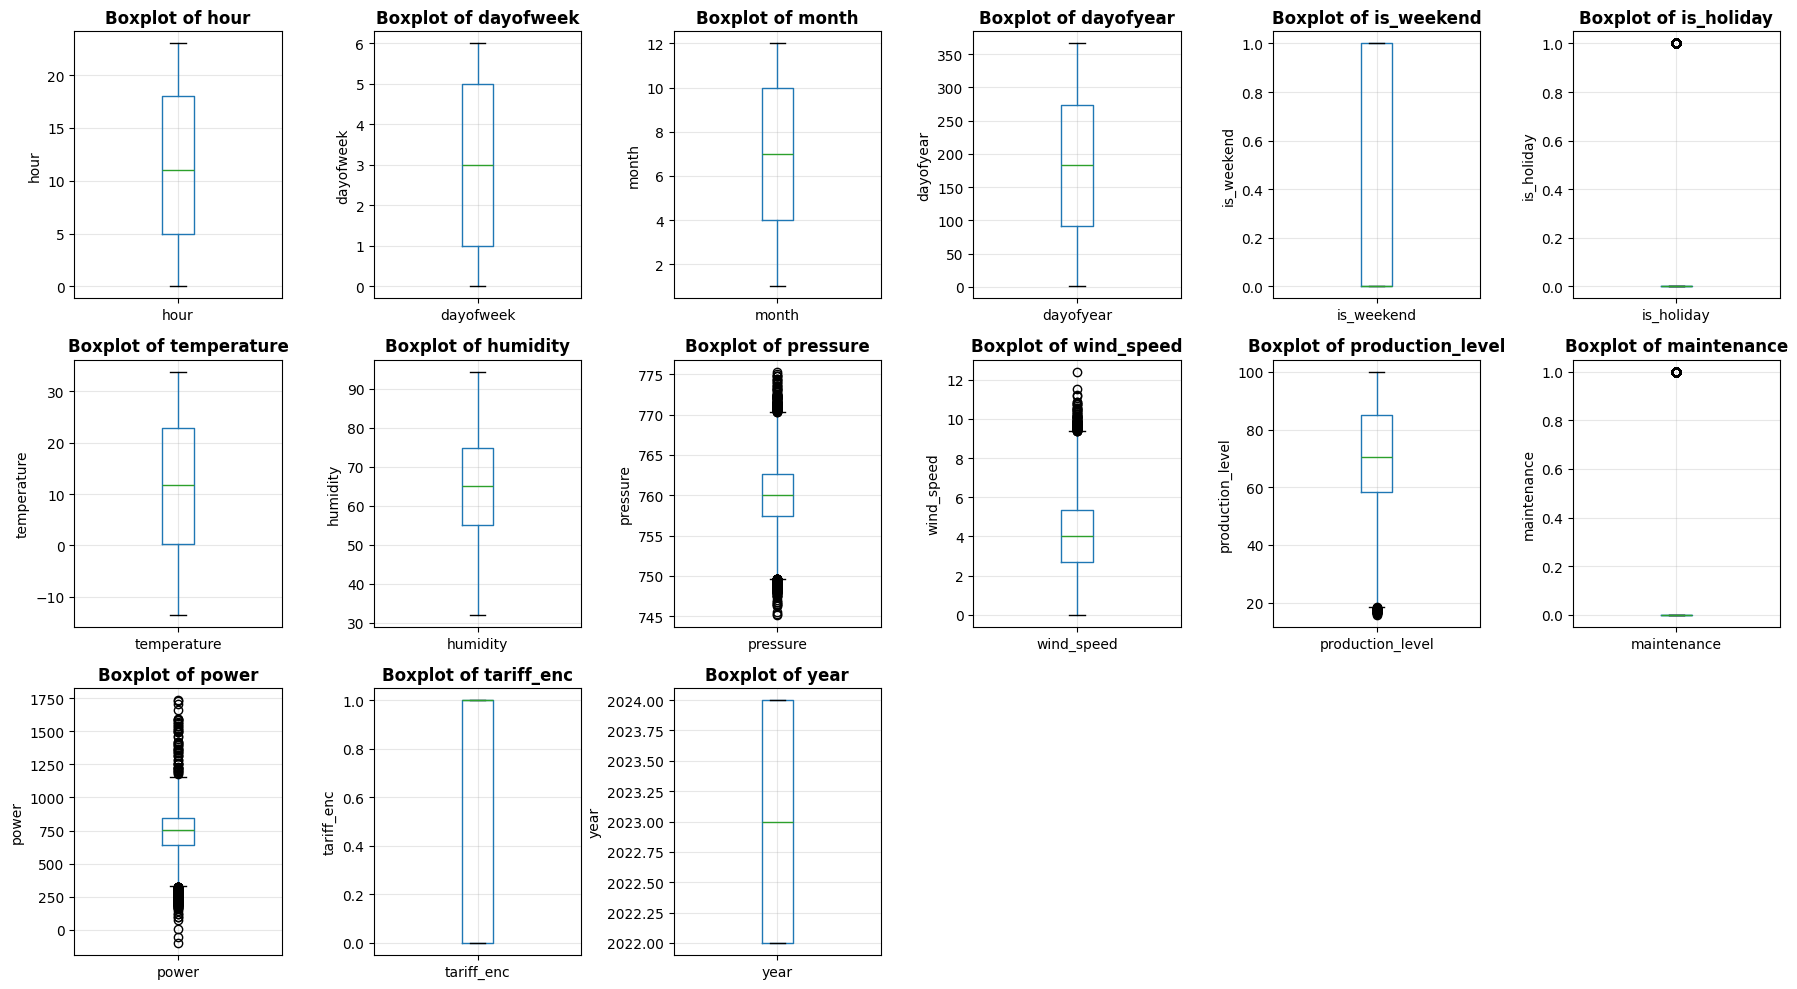

In [13]:
# Ящик с усами для проверки на наличие выбросов
num_col = df_sorted.select_dtypes(include = 'number').columns
fig, axes = plt.subplots(3, len(num_col)//3 + 1, figsize=(18, 10))
axes = axes.flatten()
for idx, col in enumerate(num_col):
    # Боксплот
    df_sorted.boxplot(column=col, ax=axes[idx])
    axes[idx].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    
for idx in range(len(num_col), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
# Проверка процента выбросов от нормального распределения значений
def Check_Outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers) / len(df) * 100

for col in ['pressure', 'wind_speed', 'production_level', 'power']:
    pct = Check_Outliers(df_sorted, col)
    print(f"{col:17}: {pct:.2f}% выбросов")

# -> Выбросов очень мало, не будем их убирать.

pressure         : 0.89% выбросов
wind_speed       : 0.36% выбросов
production_level : 0.12% выбросов
power            : 0.80% выбросов


### Визуализация таргетов по годам и дням

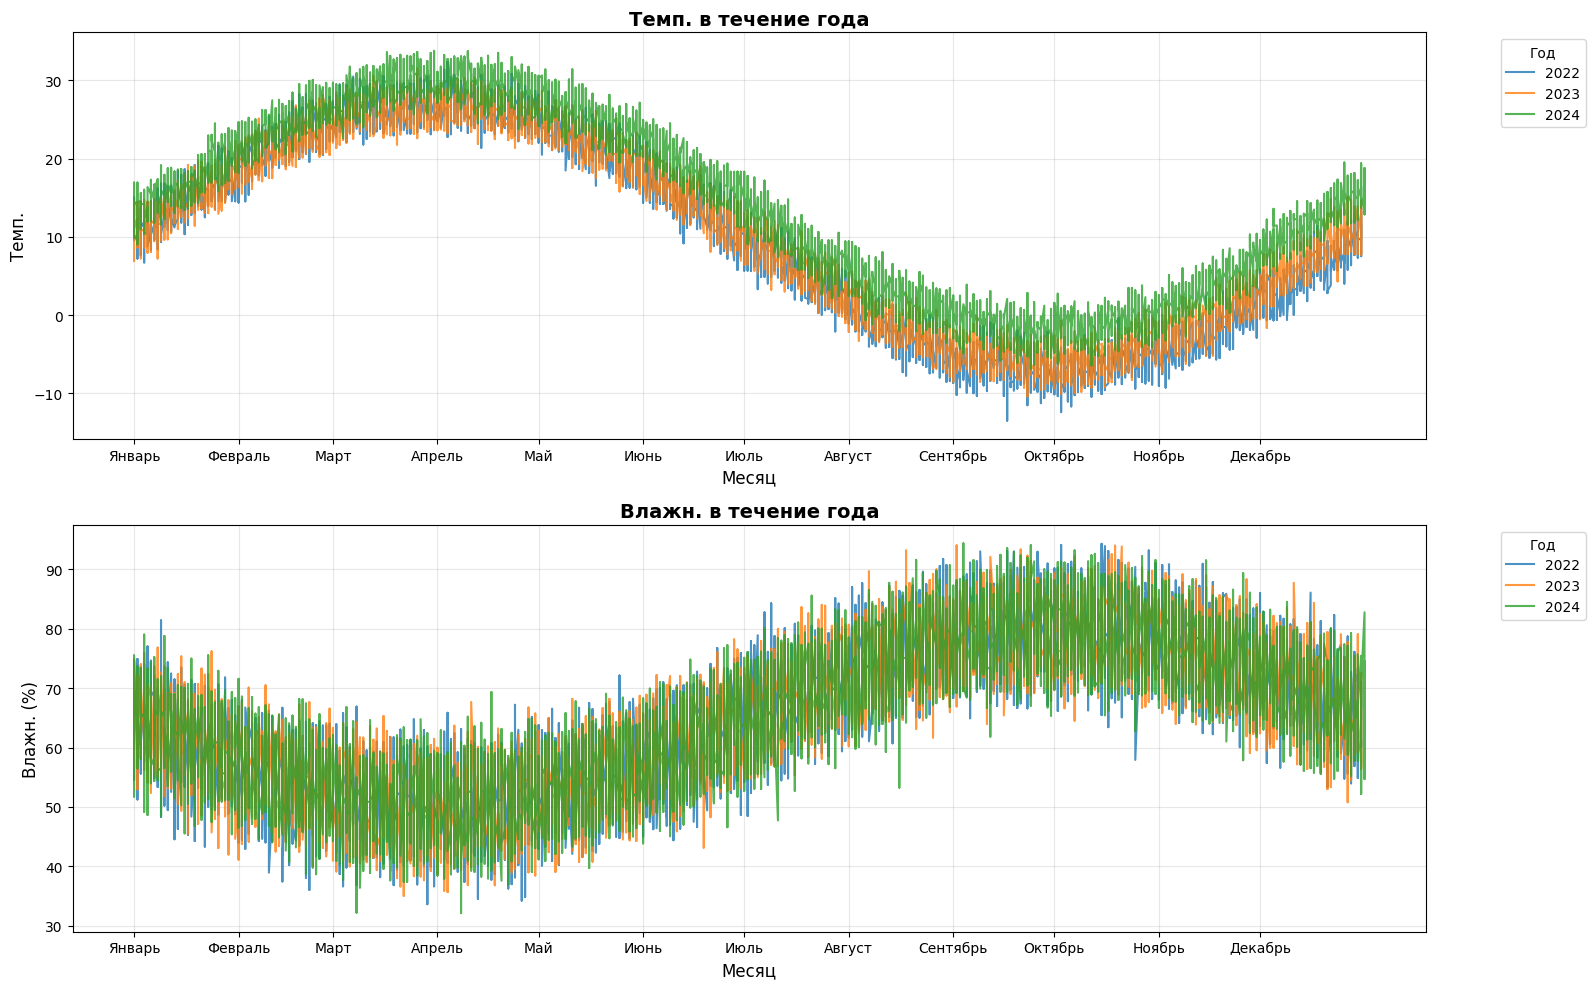

In [15]:
# Визуализация целевых переменных
fig, axes = plt.subplots(2, 1, figsize = (16, 10))

# Сортировка по году и дням в году
for year in df_sorted['year'].unique():
    year_data = df_sorted[df_sorted['year'] == year]
    axes[0].plot(year_data['dayofyear'], year_data['temperature'], 
                 label = f'{year}', linewidth=1.5, alpha=0.8)
# Температура
axes[0].set_title('Темп. в течение года', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Месяц', fontsize=12)
axes[0].set_ylabel('Темп.', fontsize=12)
axes[0].legend(title='Год', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# Добавляем метки месяцев на оси X
days_on_month = [1, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30]
month_starts = np.cumsum(days_on_month)
month_names = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 
               'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']
axes[0].set_xticks(month_starts)
axes[0].set_xticklabels(month_names)

# Влажность
for year in df_sorted['year'].unique():
    year_data = df_sorted[df_sorted['year'] == year]
    axes[1].plot(year_data['dayofyear'], year_data['humidity'], 
                label=f'{year}', linewidth=1.5, alpha=0.8)

axes[1].set_title('Влажн. в течение года', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Месяц', fontsize=12)
axes[1].set_ylabel('Влажн. (%)', fontsize=12)
axes[1].legend(title='Год', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(month_starts)
axes[1].set_xticklabels(month_names)

plt.tight_layout()
plt.show()

# Осенью холоднее чем зимой? Ну ладно...

### Формирование нового датасета

In [16]:
df_sorted.columns

Index(['timestamp', 'hour', 'dayofweek', 'month', 'dayofyear', 'is_weekend',
       'is_holiday', 'temperature', 'humidity', 'pressure', 'wind_speed',
       'production_level', 'maintenance', 'power', 'tariff', 'tariff_enc',
       'year'],
      dtype='object')

In [17]:
df_sorted = df_sorted.drop(columns = ['tariff'])
df_sorted.columns

Index(['timestamp', 'hour', 'dayofweek', 'month', 'dayofyear', 'is_weekend',
       'is_holiday', 'temperature', 'humidity', 'pressure', 'wind_speed',
       'production_level', 'maintenance', 'power', 'tariff_enc', 'year'],
      dtype='object')

In [18]:
# Получаем список всех колонок
cols = df_sorted.columns.tolist()

# Удаляем 'year' из списка и вставляем в начало
cols.remove('year')
cols = ['year'] + cols

# Применяем новый порядок
df_sorted = df_sorted.reindex(columns=cols)

In [ ]:
df_sorted.to_csv('clear_dataset.csv', index = False)

In [20]:
df_sorted

,year,timestamp,hour,dayofweek,month,dayofyear,is_weekend,is_holiday,temperature,humidity,pressure,wind_speed,production_level,maintenance,power,tariff_enc
9185,2022,2022-01-01 00:00:00,0,5,1,1,1,1,12.813583,70.815462,766.070118,5.096137,16.316179,0,493.514278,0
19594,2022,2022-01-01 01:00:00,1,5,1,1,1,1,12.418603,60.165445,764.198063,4.768088,19.847027,0,469.968603,0
17192,2022,2022-01-01 02:00:00,2,5,1,1,1,1,11.248504,56.524392,764.583261,2.740861,18.202132,0,464.957714,0
7250,2022,2022-01-01 03:00:00,3,5,1,1,1,1,14.838610,63.133580,758.682144,6.740016,16.235565,0,446.527920,0
10780,2022,2022-01-01 04:00:00,4,5,1,1,1,1,13.930495,58.701775,760.782707,5.875488,16.338017,0,376.692747,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24189,2024,2024-12-31 19:00:00,19,1,12,366,0,1,17.656832,74.951940,761.465937,2.457658,41.075627,0,786.317055,1
25917,2024,2024-12-31 20:00:00,20,1,12,366,0,1,14.700471,69.862155,761.830293,5.336193,39.277665,0,779.039162,1
22237,2024,2024-12-31 21:00:00,21,1,12,366,0,1,13.245591,66.849603,759.772171,6.065276,35.194808,0,817.030430,1
23866,2024,2024-12-31 22:00:00,22,1,12,366,0,1,18.421881,71.460126,763.011280,7.215641,32.849373,0,800.345582,0


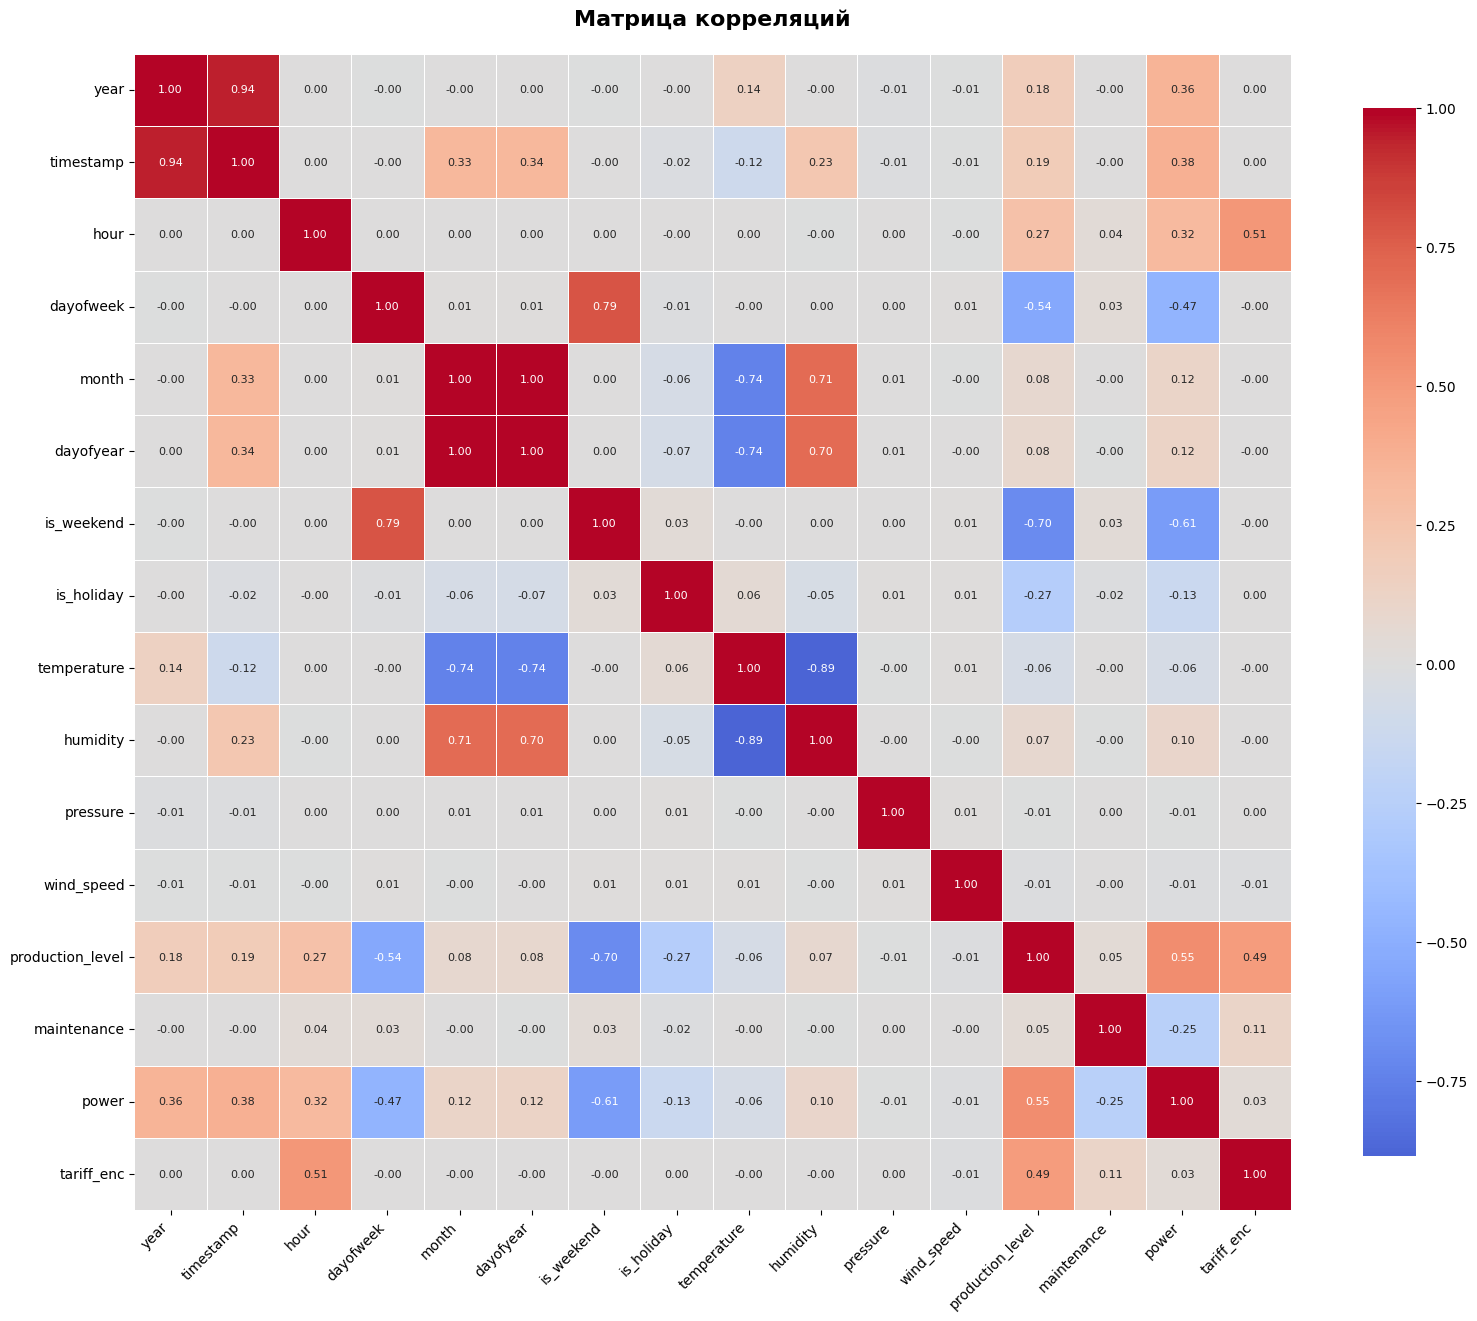

In [21]:
# Вычисляем корреляцию
corr_features = df_sorted.columns

corr_matrix = df_sorted[corr_features].corr()

# Настройка размера графика
plt.figure(figsize=(16, 14))

# Тепловая карта
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Верхний треугольник
sns.heatmap(corr_matrix, 
            # mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot_kws={'size': 8})

plt.title('Матрица корреляций', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# -> Пока так оставим, посмотрим на результаты baseline

## Построение моделей

### Добавление лагов и скользящих средних

In [ ]:
# Добавление лагов для временных рядов
def add_lag_features(df, target_cols, lags = [1, 2, 3, 6, 12, 24]):
    df_lagged = df.copy()
    for col in target_cols:
        for lag in lags:
            df_lagged[f'{col}_lag_{lag}'] = df_lagged[col].shift(lag)
    return df_lagged
df_sorted = add_lag_features(df_sorted, ['temperature', 'humidity'])

# Добавление скользящих средних
def add_rolling_features(df, target_cols, windows=[3, 6, 12, 24]):
    df_rolled = df.copy()
    for col in target_cols:
        for window in windows:
            df_rolled[f'{col}_rolling_mean_{window}'] = df_rolled[col].rolling(window).mean()
            df_rolled[f'{col}_rolling_std_{window}']  = df_rolled[col].rolling(window).std()
    return df_rolled
df_sorted = add_rolling_features(df_sorted, ['temperature', 'humidity'], windows=[3, 24])

# Удаление первых строк с NaN (из-за лагов и скользящих средних)
df_sorted = df_sorted.dropna()
df_sorted

,year,timestamp,hour,dayofweek,month,dayofyear,is_weekend,is_holiday,temperature,humidity,...,humidity_lag_12,humidity_lag_24,temperature_rolling_mean_3,temperature_rolling_std_3,temperature_rolling_mean_24,temperature_rolling_std_24,humidity_rolling_mean_3,humidity_rolling_std_3,humidity_rolling_mean_24,humidity_rolling_std_24
22559,2022,2022-01-02 00:00:00,0,6,1,2,1,1,10.401137,64.264374,...,64.050007,70.815462,11.492454,2.686623,12.137066,1.656100,65.101755,4.459583,64.544773,5.172118
22272,2022,2022-01-02 01:00:00,1,6,1,2,1,1,7.639951,66.816577,...,74.604930,60.165445,9.188101,1.410766,11.937955,1.891338,67.000540,2.832632,64.821903,5.105018
11549,2022,2022-01-02 02:00:00,2,6,1,2,1,1,9.406154,60.939157,...,70.780783,56.524392,9.149081,1.398428,11.861191,1.956793,64.006703,2.947170,65.005852,4.867027
12082,2022,2022-01-02 03:00:00,3,6,1,2,1,1,8.497684,74.926325,...,64.902581,63.133580,8.514596,0.883223,11.596985,1.965360,67.560687,7.023211,65.497216,5.250005
18284,2022,2022-01-02 04:00:00,4,6,1,2,1,1,11.183048,70.549093,...,65.734027,58.701775,9.695629,1.365885,11.482508,1.902542,68.804859,7.154857,65.990855,5.139082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24189,2024,2024-12-31 19:00:00,19,1,12,366,0,1,17.656832,74.951940,...,59.783716,54.871964,14.945100,2.348855,15.505910,1.397140,65.921657,7.895958,65.353938,7.862534
25917,2024,2024-12-31 20:00:00,20,1,12,366,0,1,14.700471,69.862155,...,64.756569,52.786477,15.330417,2.084113,15.406763,1.364631,69.103315,6.262622,66.065425,7.436926
22237,2024,2024-12-31 21:00:00,21,1,12,366,0,1,13.245591,66.849603,...,65.228598,52.200819,15.200965,2.247806,15.385709,1.394852,70.554566,4.095307,66.675791,6.825552
23866,2024,2024-12-31 22:00:00,22,1,12,366,0,1,18.421881,71.460126,...,64.300638,57.247413,15.455981,2.669567,15.522410,1.524568,69.390628,2.341150,67.267987,6.584258


In [23]:
feature_cols = [col for col in df_sorted.columns if col not in ['timestamp', 'temperature', 'humidity']]
target_cols = ['temperature', 'humidity']

### Разбиение данных

In [ ]:
# Временная разбивка (80/20)
# Обучаем на ранних данных, тестируем на более поздних
split_idx = int(len(df_sorted) * 0.8)
train_df  = df_sorted.iloc[:split_idx].copy()
test_df   = df_sorted.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_cols]
X_test  = test_df[feature_cols]
y_test  = test_df[target_cols]

In [25]:
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (21040, 33)
Размер тестовой выборки: (5260, 33)


### Базовая модель

In [26]:
# Создаем базовую модель XGBoost
xgb_model = xgb.XGBRegressor(n_estimators     = 300,
                             max_depth        = 6,
                             learning_rate    = 0.05,
                             subsample        = 0.8,
                             colsample_bytree = 0.8,
                             random_state     = 11,
                             verbosity        = 0
                            )

# Оборачиваем в MultiOutputRegressor
model = MultiOutputRegressor(xgb_model)

In [27]:
model.fit(X_train, y_train)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=11, ...))

In [28]:
y_pred = model.predict(X_test)

# Оценка для каждого target
for i, target in enumerate(target_cols):
    mse = mean_squared_error(y_test[target], y_pred[:, i])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test[target], y_pred[:, i])
    r2 = r2_score(y_test[target], y_pred[:, i])
    
    print(f"\n{target.upper()}:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")


TEMPERATURE:
  MSE:  0.4572
  RMSE: 0.6762
  MAE:  0.5332
  R²:   0.9920

HUMIDITY:
  MSE:  0.9111
  RMSE: 0.9545
  MAE:  0.6807
  R²:   0.9871


In [38]:
y_test.shape

(5260, 2)

In [39]:
y_pred.shape

(5260, 2)

In [43]:
dates = df_sorted['timestamp'].iloc[split_idx:]

<Figure size 1500x600 with 0 Axes>

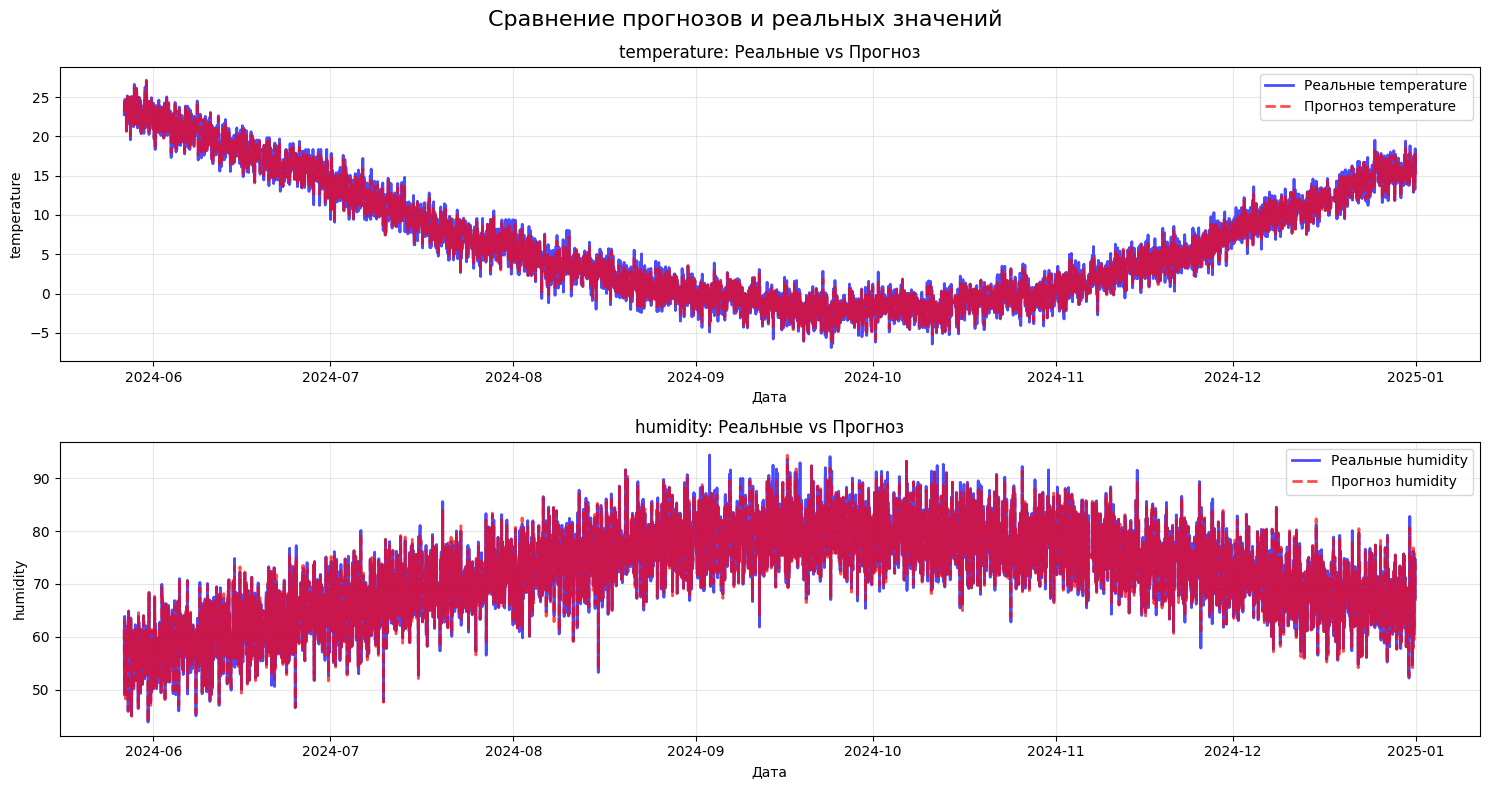

In [52]:
# Построение графика сравнения прогнозов и реальных значений.
def Plot_Predictions(y_test, y_pred, dates, title = "Сравнение прогнозов и реальных значений"):
    plt.figure(figsize=(15, 6))
    
    # Если переданы несколько целевых переменных
    if isinstance(y_test, pd.DataFrame) and y_test.shape[1] > 1:
        n_cols = y_test.shape[1]
        fig, axes = plt.subplots(n_cols, 1, figsize=(15, 4 * n_cols))
        
        if n_cols == 1:
            axes = [axes]
        
        for idx, col in enumerate(y_test.columns):
            axes[idx].plot(dates, y_test[col], label=f'Реальные {col}', 
                          color='blue', alpha=0.7, linewidth=2)
            axes[idx].plot(dates, y_pred[col], label=f'Прогноз {col}', 
                          color='red', alpha=0.7, linestyle='--', linewidth=2)
            axes[idx].set_xlabel('Дата')
            axes[idx].set_ylabel(col)
            axes[idx].set_title(f'{col}: Реальные vs Прогноз')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)
        
        plt.suptitle(title, fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        # Одиночная целевая переменная
        plt.plot(dates, y_test, label='Реальные значения', 
                color='blue', alpha=0.7, linewidth=2)
        plt.plot(dates, y_pred, label='Прогноз модели', 
                color='red', alpha=0.7, linestyle='--', linewidth=2)
        plt.xlabel('Дата')
        plt.ylabel('Значение')
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

Plot_Predictions(pd.DataFrame(y_test, columns = ['temperature', 'humidity']), pd.DataFrame(y_pred, columns = ['temperature', 'humidity']), dates)

In [40]:
X_test

,year,hour,dayofweek,month,dayofyear,is_weekend,is_holiday,pressure,wind_speed,production_level,...,humidity_lag_12,humidity_lag_24,temperature_rolling_mean_3,temperature_rolling_std_3,temperature_rolling_mean_24,temperature_rolling_std_24,humidity_rolling_mean_3,humidity_rolling_std_3,humidity_rolling_mean_24,humidity_rolling_std_24
11263,2024,1,0,5,148,0,0,761.629487,6.560845,65.285798,...,60.022286,52.598837,23.742591,1.156672,24.307521,1.420666,54.520524,6.074235,55.808284,3.573737
13149,2024,2,0,5,148,0,0,757.778844,3.980897,78.932440,...,58.623576,56.310608,23.954637,1.119614,24.324383,1.414657,53.749194,6.782061,55.505560,3.828006
6260,2024,3,0,5,148,0,0,765.326347,6.643791,68.543580,...,54.099874,54.876827,23.678240,0.767489,24.251902,1.372055,58.150890,7.973552,55.880858,4.188264
16264,2024,4,0,5,148,0,0,762.209327,5.240347,71.736277,...,56.613770,53.261207,24.311334,0.344284,24.368536,1.279034,58.483531,8.202136,56.266698,4.359480
18225,2024,5,0,5,148,0,0,761.935976,1.222755,76.839280,...,55.768065,55.117302,23.868286,1.037263,24.359663,1.290224,61.972518,2.236965,56.449820,4.401205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24189,2024,19,1,12,366,0,1,761.465937,2.457658,41.075627,...,59.783716,54.871964,14.945100,2.348855,15.505910,1.397140,65.921657,7.895958,65.353938,7.862534
25917,2024,20,1,12,366,0,1,761.830293,5.336193,39.277665,...,64.756569,52.786477,15.330417,2.084113,15.406763,1.364631,69.103315,6.262622,66.065425,7.436926
22237,2024,21,1,12,366,0,1,759.772171,6.065276,35.194808,...,65.228598,52.200819,15.200965,2.247806,15.385709,1.394852,70.554566,4.095307,66.675791,6.825552
23866,2024,22,1,12,366,0,1,763.011280,7.215641,32.849373,...,64.300638,57.247413,15.455981,2.669567,15.522410,1.524568,69.390628,2.341150,67.267987,6.584258


### Подбор гиперпараметров

In [ ]:
# Определяем сетку параметров
param_grid = {'estimator__n_estimators': [100, 200, 300],
              'estimator__max_depth': [4, 6, 8],
              'estimator__learning_rate': [0.01, 0.05, 0.1],
              'estimator__subsample': [0.7, 0.8, 0.9],
              'estimator__colsample_bytree': [0.7, 0.8, 0.9]
             }

# Создаем базовую модель
xgb_model = xgb.XGBRegressor(random_state = 11, n_jobs = -1)

# Оборачиваем в MultiOutputRegressor
model = MultiOutputRegressor(xgb_model)

# Используем TimeSeriesSplit для кросс-валидации
tscv = TimeSeriesSplit(n_splits = 3)

# Создаем GridSearch
grid_search = GridSearchCV(estimator  = model,
                           param_grid = param_grid,
                           cv         = tscv,
                           scoring    = 'neg_mean_absolute_error',
                           verbose     = 5)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 243 candidates, totalling 729 fits
[CV 1/3] END estimator__colsample_bytree=0.7, estimator__learning_rate=0.01, estimator__max_depth=4, estimator__n_estimators=100, estimator__subsample=0.7;, score=-6.795 total time=   0.3s
[CV 2/3] END estimator__colsample_bytree=0.7, estimator__learning_rate=0.01, estimator__max_depth=4, estimator__n_estimators=100, estimator__subsample=0.7;, score=-4.516 total time=   0.5s
[CV 3/3] END estimator__colsample_bytree=0.7, estimator__learning_rate=0.01, estimator__max_depth=4, estimator__n_estimators=100, estimator__subsample=0.7;, score=-4.737 total time=   0.7s
[CV 1/3] END estimator__colsample_bytree=0.7, estimator__learning_rate=0.01, estimator__max_depth=4, estimator__n_estimators=100, estimator__subsample=0.8;, score=-6.795 total time=   0.6s
[CV 2/3] END estimator__colsample_bytree=0.7, estimator__learning_rate=0.01, estimator__max_depth=4, estimator__n_estimators=100, estimator__subsample=0.8;, score=-4.516 total time=

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=MultiOutputRegressor(estimator=XGBRegressor(base_score=None,
                                                                   booster=None,
                                                                   callbacks=None,
                                                                   colsample_bylevel=None,
                                                                   colsample_bynode=None,
                                                                   colsample_bytree=None,
                                                                   device=None,
                                                                   early_stopping_rounds=None,
                                                                   enable_categorical=False,
                                                                   eval_metric=None,
                                                                   feature_types=None,...
                                                                   monotone_constraints=None,
                                                                   multi_strategy=None,
                                                                   n_estimators=None,
                                                                   n_jobs=-1,
                                                                   num_parallel_tree=None,
                                                                   random_state=11, ...)),
             param_grid={'estimator__colsample_bytree': [0.7, 0.8, 0.9],
                         'estimator__learning_rate': [0.01, 0.05, 0.1],
                         'estimator__max_depth': [4, 6, 8],
                         'estimator__n_estimators': [100, 200, 300],
                         'estimator__subsample': [0.7, 0.8, 0.9]},
             scoring='neg_mean_absolute_error', verbose=5)

In [186]:
# Лучшие гиперпараметры
for param, value in grid_search.best_params_.items():
    # Убираем префикс 'estimator__' для вывода
    clean_param = param.replace('estimator__', '')
    print(f"  {clean_param}: {value}")

  colsample_bytree: 0.9
  learning_rate: 0.1
  max_depth: 6
  n_estimators: 300
  subsample: 0.9


In [ ]:
# Предсказания для лучшей модели
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Оценка для каждого target
for i, target in enumerate(target_cols):
    mse = mean_squared_error(y_test[target], y_pred[:, i])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test[target], y_pred[:, i])
    r2 = r2_score(y_test[target], y_pred[:, i])
    
    print(f"\n{target.upper()}:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")


TEMPERATURE:
  MSE:  0.1481
  RMSE: 0.3848
  MAE:  0.2975
  R²:   0.9974

HUMIDITY:
  MSE:  0.6174
  RMSE: 0.7857
  MAE:  0.5518
  R²:   0.9913


<Figure size 1500x600 with 0 Axes>

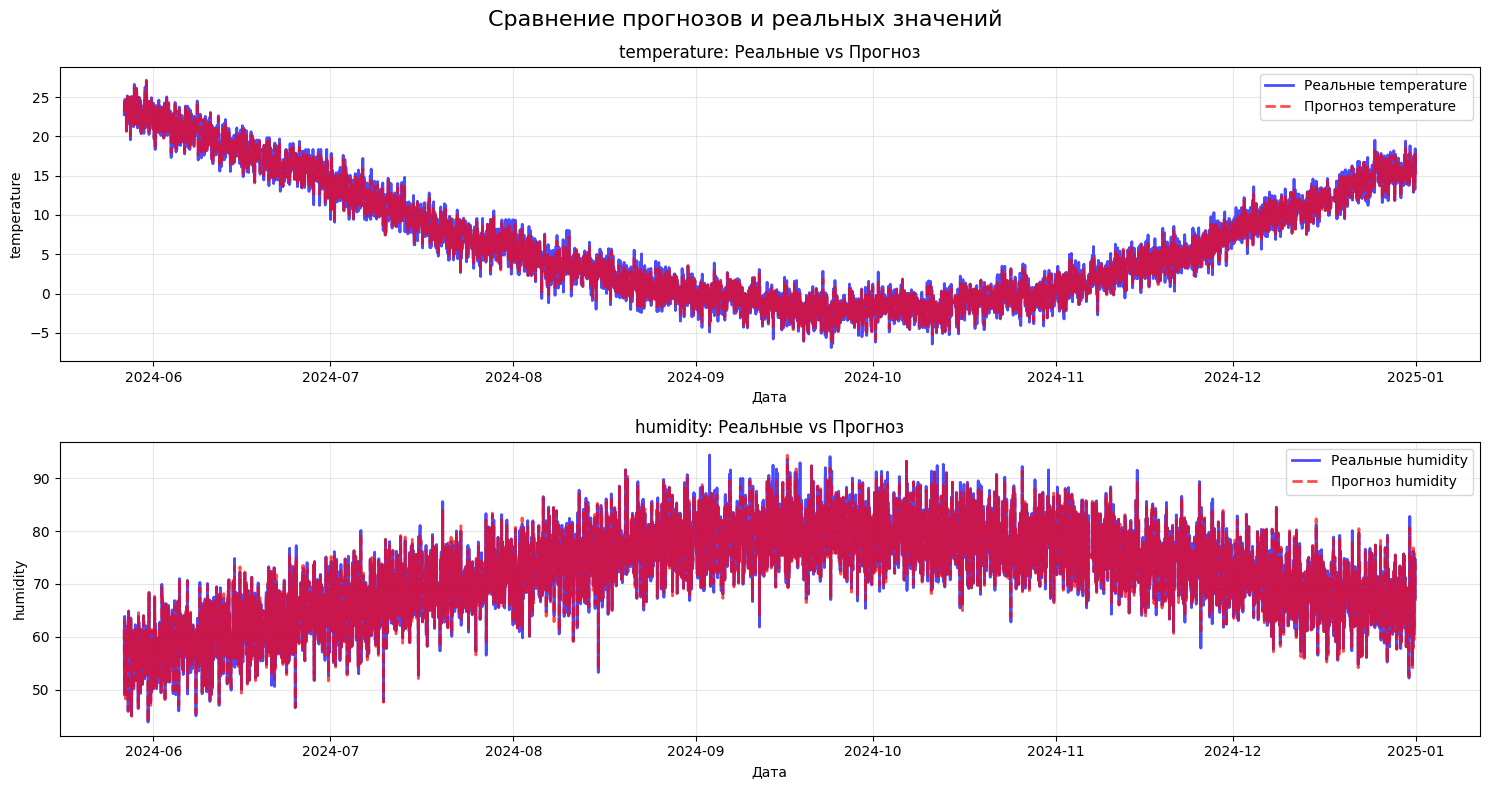

In [53]:
Plot_Predictions(pd.DataFrame(y_test, columns = ['temperature', 'humidity']), pd.DataFrame(y_pred, columns = ['temperature', 'humidity']), dates)

На основе этих результатов описан класс в файле model.py c пайплайн подготовки данных (лаги + окна), обучением и тестированием модели для прогнозирования временных рядов.

## Результаты работы класса

In [29]:
from model import WeatherPredictor

In [30]:
predictor = WeatherPredictor()

predictor.train(df_sorted)

Модель обучается.

Метрики: 
temperature: MAE  = 0.3020 RMSE = 0.3941 R2   = 0.9973 
humidity: MAE  = 0.4922 RMSE = 0.7215 R2   = 0.9926 


In [31]:
print(predictor.evaluate(df_sorted))

{'temperature': {'MAE': 0.30198757503152873, 'RMSE': 0.3940588025485907, 'R2': 0.9972779461162908}, 'humidity': {'MAE': 0.49220594569671305, 'RMSE': 0.7215147431569296, 'R2': 0.9926450826352774}}


In [32]:
history = df_sorted[:-2]
prediction = predictor.predict_next_hour(history)

print(prediction)

{'temperature': 13.193244934082031, 'humidity': 66.63188171386719}


In [33]:
prediction = predictor.predict_24_hours(history)
print("Следующие 24 часа:")

for t, temp, hum in zip(prediction["timestamp"],
                        prediction["temperature"],
                        prediction["humidity"]
                       ):

        print(t,
              f"{temp:.2f}",
              f"{hum:.2f}"
             )

Следующие 24 часа:
2024-12-31 22:00:00 13.19 66.63
2024-12-31 23:00:00 13.27 65.94
2025-01-01 00:00:00 13.20 66.51
2025-01-01 01:00:00 13.18 67.15
2025-01-01 02:00:00 13.05 66.90
2025-01-01 03:00:00 13.02 66.57
2025-01-01 04:00:00 13.17 65.77
2025-01-01 05:00:00 13.24 66.46
2025-01-01 06:00:00 13.15 67.12
2025-01-01 07:00:00 13.07 66.98
2025-01-01 08:00:00 13.03 66.77
2025-01-01 09:00:00 13.05 66.41
2025-01-01 10:00:00 13.14 66.21
2025-01-01 11:00:00 13.23 66.91
2025-01-01 12:00:00 13.16 67.16
2025-01-01 13:00:00 13.07 66.73
2025-01-01 14:00:00 13.00 66.68
2025-01-01 15:00:00 12.99 65.90
2025-01-01 16:00:00 12.56 66.50
2025-01-01 17:00:00 12.72 67.22
2025-01-01 18:00:00 12.74 67.05
2025-01-01 19:00:00 13.16 66.63
2025-01-01 20:00:00 13.44 66.64
2025-01-01 21:00:00 13.39 66.46


In [34]:
predictor.save_model()

Модель сохранена в weather_predictor.pkl


In [35]:
predictor.load_model()

Модель загружена.
